In [15]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import numpy as np
import geopandas as gpd

In [16]:
# --
ds_rd = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-radiation-heat_bau786p.nc')

# --
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

In [17]:
# --
ds_rd

<xarray.Dataset> Size: 29MB
Dimensions:     (valid_time: 70176, latitude: 10, longitude: 10)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-12-31 ... 2026-01-01T2...
  * latitude    (latitude) float64 80B -32.0 -31.9 -31.8 ... -31.3 -31.2 -31.1
  * longitude   (longitude) float64 80B -64.9 -64.8 -64.7 ... -64.2 -64.1 -64.0
Data variables:
    ssrd        (valid_time, latitude, longitude) float32 28MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-03-04T23:33 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [18]:
#ds_rd.ssrd.values[0:25, 0, 0], ds_rd.valid_time.values[0:25]

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

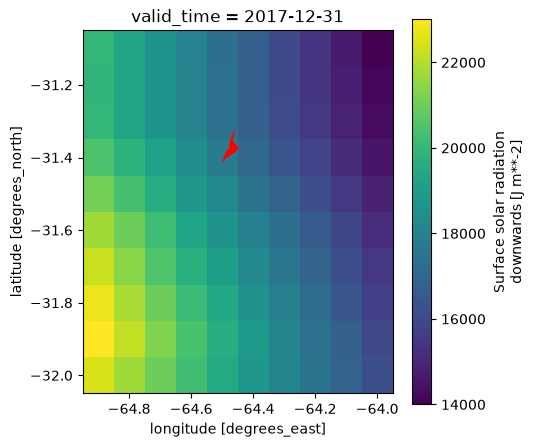

In [19]:
# --
fig, ax = plt.subplots(figsize=(5, 5))
ds_rd.isel(valid_time=0).ssrd.plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [20]:
# --
ds_rd = ds_rd.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_rd = ds_rd.rio.write_crs("EPSG:4326", inplace=False)

# --
ds_clip = ds_rd.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

In [21]:
# --
'''
Amount of solar radiation (also known as shortwave radiation) reaching the surface of the Earth. This variable comprises both direct and 
diffuse solar radiation. Radiation from the Sun (solar, or shortwave, radiation) is partly reflected back to space by clouds and particles 
in the atmosphere (aerosols) and some of it is absorbed. The rest is incident on the Earth's surface (represented by this variable). To a 
reasonably good approximation, this variable is the model equivalent of what would be measured by a pyranometer (an instrument used for 
measuring solar radiation) at the surface. However, care should be taken when comparing model variables with observations, because 
observations are often local to a particular point in space and time, rather than representing averages over a model grid box and model 
time step. This variable is accumulated from the beginning of the forecast time to the end of the forecast step. The units are joules per 
square metre (J m^-2). To convert to watts per square metre (W m^-2), the accumulated values should be divided by the accumulation period 
expressed in seconds. The ECMWF convention for vertical fluxes is positive downwards.

Measurement at 00:00:00 is the accumulated for the day before
'''

# --
rd_spatial_medn = ds_clip.ssrd.median(dim=['latitude', 'longitude'])
rd_spatial_medn = rd_spatial_medn.sel(valid_time=slice('2023-01-01', '2026-01-01'))
rd_spatial_medn_res = rd_spatial_medn.resample(valid_time='1D').max()#.values[:-1]

# --
dates_norm = rd_spatial_medn_res.valid_time.values.astype('datetime64[D]')
rd_ttss_corr = np.concatenate((rd_spatial_medn_res.values[1:], np.array([0])))


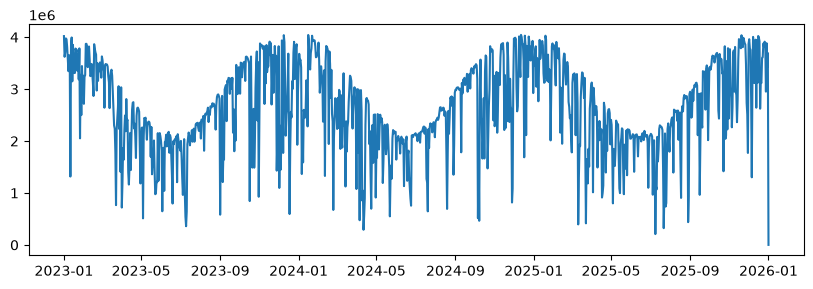

In [23]:
# --
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dates_norm, rd_ttss_corr)

In [24]:
# --
df_rd_ttss = pd.DataFrame({'yy-mm-dd': dates_norm, 'RD_ERA5-Jm2': rd_ttss_corr})

# --
df_rd_ttss.head(5)

,yy-mm-dd,RD_ERA5-Jm2
0,2023-01-01,4020688.0
1,2023-01-02,3622236.0
2,2023-01-03,3707736.0
3,2023-01-04,3976584.0
4,2023-01-05,3959032.0


In [25]:
# --
df_rd_ttss.to_csv('output/rd_ttss_2326.csv', index=False)